# R(2) pure-Z reference equivalence check

This notebook checks that pure-Z light gives the same photon-count scan when
the OBE system is generated with an X reference transition plus an explicit Z
polarization component, versus when it is generated directly with a Z reference
transition.

The comparison is made at the same physical laser frequencies. The plotted
axis is detuning from the X-reference transition.


In [1]:
from __future__ import annotations

from dataclasses import dataclass
import inspect
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sympy as smp
from centrex_tlf import couplings, hamiltonian, lindblad, states, transitions
from centrex_tlf.lindblad.parameters import LindbladParameters
from centrex_tlf.lindblad.plan_static import prepare_lindblad_problem
from centrex_tlf.utils import population
from centrex_tlf.utils.rabi import (
    power_to_intensity_rectangular_beam,
    power_to_rabi_rectangular_beam,
)

plt.rcParams.update({"font.size": 13})

GAMMA = getattr(hamiltonian, "Γ")


## Configuration


In [2]:
transition = transitions.R2_F1_7o2_F3

E_FIELD_Z_V_CM = 171.6
E_FIELD = np.array([0.0, 0.0, E_FIELD_Z_V_CM])
B_FIELD = np.array([0.0, 0.0, 1e-5])

POWER_MW = 40.0
POWER_W = POWER_MW * 1e-3

BEAM_WX = 0.02
BEAM_WY = 0.02
VELOCITY = 184.0
INTERACTION_LENGTH = 0.02
T_END = INTERACTION_LENGTH / VELOCITY

INITIAL_F1 = 5 / 2
INITIAL_F = 2
INITIAL_MF = 0

INITIAL_POPULATION_SELECTORS = [
    states.QuantumSelector(J=2, F1=INITIAL_F1, F=INITIAL_F, mF=INITIAL_MF),
    states.QuantumSelector(J=2, F1=INITIAL_F1, F=INITIAL_F + 1, mF=-1),
    states.QuantumSelector(J=2, F1=INITIAL_F1, F=INITIAL_F + 1, mF=0),
    states.QuantumSelector(J=2, F1=INITIAL_F1, F=INITIAL_F + 1, mF=+1),
]
INITIAL_POPULATION_WEIGHTS = np.array([2 / 3, 1 / 9, 1 / 9, 1 / 9], dtype=float)

SHARED_X_REFERENCE_DETUNING_MHZ = np.linspace(-80.0, 80.0, 161)
SCAN_SAVEAT = np.linspace(0.0, T_END, 801)
SCAN_THREADS = None

FIT_REL_TOL = 1e-7
FIT_ABS_TOL = 1e-9

RABI_PARAMETER_NAME = "rabi"
DETUNING_PARAMETER_NAME = "detuning"
X_POLARIZATION_PARAMETER_NAME = "polarization_x"
Z_POLARIZATION_PARAMETER_NAME = "polarization_z"

ASSERT_RTOL = 1e-8
ASSERT_ATOL = 1e-10

config = {
    "transition": transition.name,
    "E_field_V_per_cm": E_FIELD.tolist(),
    "power_mW": POWER_MW,
    "beam_cm_by_cm": (BEAM_WX * 100, BEAM_WY * 100),
    "intensity_mW_per_cm2": power_to_intensity_rectangular_beam(POWER_W, BEAM_WX, BEAM_WY) * 0.1,
    "velocity_m_per_s": VELOCITY,
    "interaction_time_us": T_END * 1e6,
    "scan_detuning_MHz": (
        float(SHARED_X_REFERENCE_DETUNING_MHZ[0]),
        float(SHARED_X_REFERENCE_DETUNING_MHZ[-1]),
        int(SHARED_X_REFERENCE_DETUNING_MHZ.size),
    ),
}
config


{'transition': "R(2) F1'=7/2 F'=3",
 'E_field_V_per_cm': [0.0, 0.0, 171.6],
 'power_mW': 40.0,
 'beam_cm_by_cm': (2.0, 2.0),
 'intensity_mW_per_cm2': 10.0,
 'velocity_m_per_s': 184.0,
 'interaction_time_us': 108.69565217391305,
 'scan_detuning_MHz': (-80.0, 80.0, 161)}

## Model construction


In [3]:
def coupled_ground_main() -> states.CoupledState:
    return 1 * next(
        iter(
            states.generate_coupled_states_X(
                states.QuantumSelector(
                    electronic=states.ElectronicState.X,
                    J=transition.J_ground,
                    F1=INITIAL_F1,
                    F=INITIAL_F,
                    mF=INITIAL_MF,
                    P=transition.P_ground,
                )
            )
        )
    )


def coupled_excited_main(mF: int) -> states.CoupledState:
    return 1 * next(
        iter(
            states.generate_coupled_states_B(
                states.QuantumSelector(
                    electronic=states.ElectronicState.B,
                    J=transition.J_excited,
                    F1=transition.F1_excited,
                    F=transition.F_excited,
                    mF=mF,
                    P=transition.P_excited,
                )
            )
        )
    )


ground_main = coupled_ground_main()
excited_main_x_ref = coupled_excited_main(mF=1)
excited_main_z_ref = coupled_excited_main(mF=0)


def selected_initial_population_indices_and_weights(
    system: lindblad.OBESystem,
) -> tuple[np.ndarray, np.ndarray]:
    index_groups = []
    for selector in INITIAL_POPULATION_SELECTORS:
        group = np.asarray(selector.get_indices(system.QN), dtype=int).ravel()
        if group.size == 0:
            raise ValueError(f"Initial population selector matched no states: {selector}")
        index_groups.append(group)

    indices = np.concatenate(index_groups)
    weights = np.concatenate(
        [
            np.full(group.size, selector_weight / group.size, dtype=float)
            for group, selector_weight in zip(index_groups, INITIAL_POPULATION_WEIGHTS)
        ]
    )
    return indices, weights


def weighted_population_fallback(
    indices: np.ndarray, levels: int, weights: np.ndarray
) -> np.ndarray:
    rho0 = np.zeros((levels, levels), dtype=np.complex128)
    np.add.at(rho0, (indices, indices), weights)
    return rho0 / np.trace(rho0)


def initial_density_matrix(system: lindblad.OBESystem) -> np.ndarray:
    indices, weights = selected_initial_population_indices_and_weights(system)

    sig = inspect.signature(population.generate_uniform_population_state_indices)
    if "weights" in sig.parameters:
        return population.generate_uniform_population_state_indices(
            indices,
            len(system.QN),
            weights=weights,
        )

    return weighted_population_fallback(indices, len(system.QN), weights)


def excited_indices(system: lindblad.OBESystem) -> list[int]:
    return [
        idx
        for idx, state in enumerate(system.QN)
        if state.largest.electronic_state == states.ElectronicState.B
    ]


In [4]:
@dataclass(frozen=True)
class PreparedReferenceModel:
    name: str
    reference_mF: int
    transition_selector: couplings.TransitionSelector
    system: lindblad.OBESystem
    params: LindbladParameters
    prepared: object
    rho0: np.ndarray
    photon_integral_weights: list[tuple[int, float]]
    x_polarization_amplitude: float | None
    z_polarization_amplitude: float | None
    build_seconds: float


def parameter_values(
    system: lindblad.OBESystem,
    transition_selector: couplings.TransitionSelector,
    *,
    has_split_xz_polarization: bool,
) -> LindbladParameters:
    params = LindbladParameters()
    rabi = params.real(RABI_PARAMETER_NAME, 0.0)
    detuning = params.real(DETUNING_PARAMETER_NAME, 0.0)

    for symbol in system.H_symbolic.free_symbols:
        name = str(symbol)
        if symbol in system.coupling_symbols:
            params.bind(symbol, rabi, finalize=False)
        elif name == str(getattr(transition_selector, "δ")):
            params.bind(symbol, detuning, finalize=False)
        else:
            params.real(name, 0.0)

    if has_split_xz_polarization:
        polarization_amplitudes = [
            params.real(X_POLARIZATION_PARAMETER_NAME, 1.0),
            params.real(Z_POLARIZATION_PARAMETER_NAME, 0.0),
        ]
    else:
        polarization_amplitudes = [1.0]

    for symbol_group in system.polarization_symbols:
        symbols = symbol_group if isinstance(symbol_group, (list, tuple)) else [symbol_group]
        for idx, symbol in enumerate(symbols):
            value = polarization_amplitudes[idx] if idx < len(polarization_amplitudes) else 1.0
            params.bind(symbol, value, finalize=False)

    params._finalize()
    return params


def build_model(
    *,
    name: str,
    reference_mF: int,
    polarizations: list[couplings.Polarization],
    excited_main: states.CoupledState,
    has_split_xz_polarization: bool,
    x_polarization_amplitude: float | None,
    z_polarization_amplitude: float | None,
) -> PreparedReferenceModel:
    transition_selectors = couplings.generate_transition_selectors(
        transitions=[transition],
        polarizations=[polarizations],
        ground_mains=[ground_main],
        excited_mains=[excited_main],
    )
    ts = transition_selectors[0]

    start = time.perf_counter()
    system = lindblad.generate_OBE_system_transitions(
        [transition],
        transition_selectors,
        qn_compact=True,
        E=E_FIELD,
        B=B_FIELD,
        retain_opposite_parity_levels=True,
        method="matrix",
        normalize_pol=True,
    )
    params = parameter_values(
        system,
        ts,
        has_split_xz_polarization=has_split_xz_polarization,
    )
    prepared = prepare_lindblad_problem(
        system,
        params,
        backend="rust",
        hamiltonian_representation="decomposed",
    )
    rho0 = initial_density_matrix(system)
    weights = [(int(idx), float(GAMMA)) for idx in excited_indices(system)]
    elapsed = time.perf_counter() - start

    return PreparedReferenceModel(
        name=name,
        reference_mF=reference_mF,
        transition_selector=ts,
        system=system,
        params=params,
        prepared=prepared,
        rho0=rho0,
        photon_integral_weights=weights,
        x_polarization_amplitude=x_polarization_amplitude,
        z_polarization_amplitude=z_polarization_amplitude,
        build_seconds=elapsed,
    )


x_reference_pure_z_model = build_model(
    name="X reference, pure Z amplitudes",
    reference_mF=1,
    polarizations=[couplings.polarization_X, couplings.polarization_Z],
    excited_main=excited_main_x_ref,
    has_split_xz_polarization=True,
    x_polarization_amplitude=0.0,
    z_polarization_amplitude=1.0,
)

z_reference_model = build_model(
    name="Z reference",
    reference_mF=0,
    polarizations=[couplings.polarization_Z],
    excited_main=excited_main_z_ref,
    has_split_xz_polarization=False,
    x_polarization_amplitude=None,
    z_polarization_amplitude=None,
)


C:\Users\ogras\Documents\GitHub\CeNTREX-TlF\centrex_tlf\states\find_states.py:564: UserWarning: Low overlap detected for approximate states at indices [0, 1, 12, 13]. Overlaps: [0.4963147486797635, 0.4962686894496859, 0.4963147485937052, 0.4962686894587732]. The approximate states may not be well-represented in the eigenstate basis.
  indices = find_exact_states_indices(
C:\Users\ogras\Documents\GitHub\CeNTREX-TlF\centrex_tlf\states\find_states.py:564: UserWarning: Low overlap detected for approximate states at indices [8, 10]. Overlaps: [0.48252736332044555, 0.48252732856599473]. The approximate states may not be well-represented in the eigenstate basis.
  indices = find_exact_states_indices(
C:\Users\ogras\Documents\GitHub\CeNTREX-TlF\centrex_tlf\states\find_states.py:564: UserWarning: Low overlap detected for approximate states at indices [0, 1, 12, 13]. Overlaps: [0.4963147486797635, 0.4962686894496859, 0.4963147485937052, 0.4962686894587732]. The approximate states may not be well

## Reference frequency alignment


In [5]:
def state_index_for_largest(system: lindblad.OBESystem, target: states.CoupledState) -> int:
    target_largest = target.largest
    matches = [idx for idx, state in enumerate(system.QN) if state.largest == target_largest]
    if len(matches) != 1:
        raise ValueError(f"Expected exactly one match for {target_largest}, found {len(matches)}")
    return matches[0]


def symbolic_diagonal_offset_mhz(
    model: PreparedReferenceModel,
    target_state: states.CoupledState,
) -> float:
    idx = state_index_for_largest(model.system, target_state)
    expr = model.system.H_symbolic[idx, idx]
    val = complex(smp.N(expr.subs({getattr(model.transition_selector, "δ"): 0})))
    return float(np.real(val) / (2 * np.pi * 1e6))


def rabi_rate_for_power(model: PreparedReferenceModel, power_w: float) -> float:
    main_coupling = abs(model.system.couplings[0].main_coupling)
    return power_to_rabi_rectangular_beam(
        power_w,
        main_coupling,
        BEAM_WX,
        BEAM_WY,
    )


z_reference_on_x_axis_mhz = symbolic_diagonal_offset_mhz(
    x_reference_pure_z_model,
    z_reference_model.transition_selector.excited_main,
)
z_detuning_for_shared_axis_mhz = SHARED_X_REFERENCE_DETUNING_MHZ - z_reference_on_x_axis_mhz

metadata_rows = []
for model, scan_axis in [
    (x_reference_pure_z_model, SHARED_X_REFERENCE_DETUNING_MHZ),
    (z_reference_model, z_detuning_for_shared_axis_mhz),
]:
    ts = model.transition_selector
    metadata_rows.append(
        {
            "model": model.name,
            "reference_mF": model.reference_mF,
            "levels": len(model.system.QN),
            "excited_levels": len(model.photon_integral_weights),
            "polarization_symbols": [
                str(s) for group in model.system.polarization_symbols for s in group
            ],
            "main_coupling": model.system.couplings[0].main_coupling,
            "rabi_MHz": rabi_rate_for_power(model, POWER_W) / (2 * np.pi * 1e6),
            "reference_on_x_axis_MHz": (
                0.0 if model is x_reference_pure_z_model else z_reference_on_x_axis_mhz
            ),
            "scan_detuning_min_MHz": float(scan_axis[0]),
            "scan_detuning_max_MHz": float(scan_axis[-1]),
            "build_seconds": model.build_seconds,
        }
    )

metadata_df = pd.DataFrame(metadata_rows)
metadata_df


,model,reference_mF,levels,excited_levels,polarization_symbols,main_coupling,rabi_MHz,reference_on_x_axis_MHz,scan_detuning_min_MHz,scan_detuning_max_MHz,build_seconds
0,"X reference, pure Z amplitudes",1,38,14,"[PX0, PZ0]",-0.233755+0.000000j,0.258314,0.000000,-80.000000,80.000000,9.057658
1,Z reference,0,38,14,[PZ0],0.520648+0.000000j,0.575349,9.968299,-89.968299,70.031701,6.861067


## Full scans


In [6]:
def photon_count_frequency_scan(
    model: PreparedReferenceModel,
    model_detuning_MHz: np.ndarray,
    *,
    power_w: float = POWER_W,
    reltol: float = FIT_REL_TOL,
    abstol: float = FIT_ABS_TOL,
    threads: int | None = SCAN_THREADS,
) -> dict[str, object]:
    rabi = rabi_rate_for_power(model, power_w)
    scan = {
        DETUNING_PARAMETER_NAME: 2 * np.pi * 1e6 * np.asarray(model_detuning_MHz, dtype=float),
        RABI_PARAMETER_NAME: np.array([rabi], dtype=float),
    }
    if model.x_polarization_amplitude is not None:
        scan[X_POLARIZATION_PARAMETER_NAME] = np.array(
            [model.x_polarization_amplitude], dtype=float
        )
    if model.z_polarization_amplitude is not None:
        scan[Z_POLARIZATION_PARAMETER_NAME] = np.array(
            [model.z_polarization_amplitude], dtype=float
        )

    result = lindblad.grid_scan(
        model.prepared,
        model.rho0,
        (0.0, T_END),
        scan=scan,
        solver="dopri5",
        execution_mode="expanded_sparse",
        output="photon_integral",
        output_when="saveat",
        integral_weights=model.photon_integral_weights,
        saveat=SCAN_SAVEAT,
        dt=2e-9,
        reltol=reltol,
        abstol=abstol,
        parallel=True,
        threads=threads,
        collect_stats=True,
    )

    photons = result.values.reshape(model_detuning_MHz.size, -1, SCAN_SAVEAT.size)[:, 0, -1]
    return {
        "model_detuning_MHz": np.asarray(model_detuning_MHz, dtype=float),
        "photons": photons,
        "rabi_rad_s": rabi,
        "rabi_MHz": rabi / (2 * np.pi * 1e6),
        "result": result,
    }


scan_x_reference_pure_z = photon_count_frequency_scan(
    x_reference_pure_z_model,
    SHARED_X_REFERENCE_DETUNING_MHZ,
)
scan_z_reference = photon_count_frequency_scan(
    z_reference_model,
    z_detuning_for_shared_axis_mhz,
)

scan_summary = {
    "shared_axis_points": int(SHARED_X_REFERENCE_DETUNING_MHZ.size),
    "x_reference_scan_shape": scan_x_reference_pure_z["photons"].shape,
    "z_reference_scan_shape": scan_z_reference["photons"].shape,
    "x_reference_rabi_MHz": scan_x_reference_pure_z["rabi_MHz"],
    "z_reference_rabi_MHz": scan_z_reference["rabi_MHz"],
}
scan_summary


{'shared_axis_points': 161,
 'x_reference_scan_shape': (161,),
 'z_reference_scan_shape': (161,),
 'x_reference_rabi_MHz': np.float64(0.2583135050561148),
 'z_reference_rabi_MHz': np.float64(0.5753486973986415)}

## Equality check


In [7]:
photons_x_reference = scan_x_reference_pure_z["photons"]
photons_z_reference = scan_z_reference["photons"]
residual = photons_x_reference - photons_z_reference
scale = np.maximum(
    np.maximum(np.abs(photons_x_reference), np.abs(photons_z_reference)), ASSERT_ATOL
)
relative_residual = residual / scale

comparison_summary = pd.DataFrame(
    [
        {
            "max_abs_difference": float(np.max(np.abs(residual))),
            "rms_difference": float(np.sqrt(np.mean(residual**2))),
            "max_relative_difference": float(np.max(np.abs(relative_residual))),
            "x_reference_peak": float(np.max(photons_x_reference)),
            "z_reference_peak": float(np.max(photons_z_reference)),
            "peak_difference": float(np.max(photons_x_reference) - np.max(photons_z_reference)),
            "allclose": bool(
                np.allclose(
                    photons_x_reference, photons_z_reference, rtol=ASSERT_RTOL, atol=ASSERT_ATOL
                )
            ),
            "assert_rtol": ASSERT_RTOL,
            "assert_atol": ASSERT_ATOL,
        }
    ]
)
comparison_summary


,max_abs_difference,rms_difference,max_relative_difference,x_reference_peak,z_reference_peak,peak_difference,allclose,assert_rtol,assert_atol
0,3.156087e-13,3.334741e-14,3.462660e-12,1.097819,1.097819,8.881784e-16,True,1.000000e-08,1.000000e-10


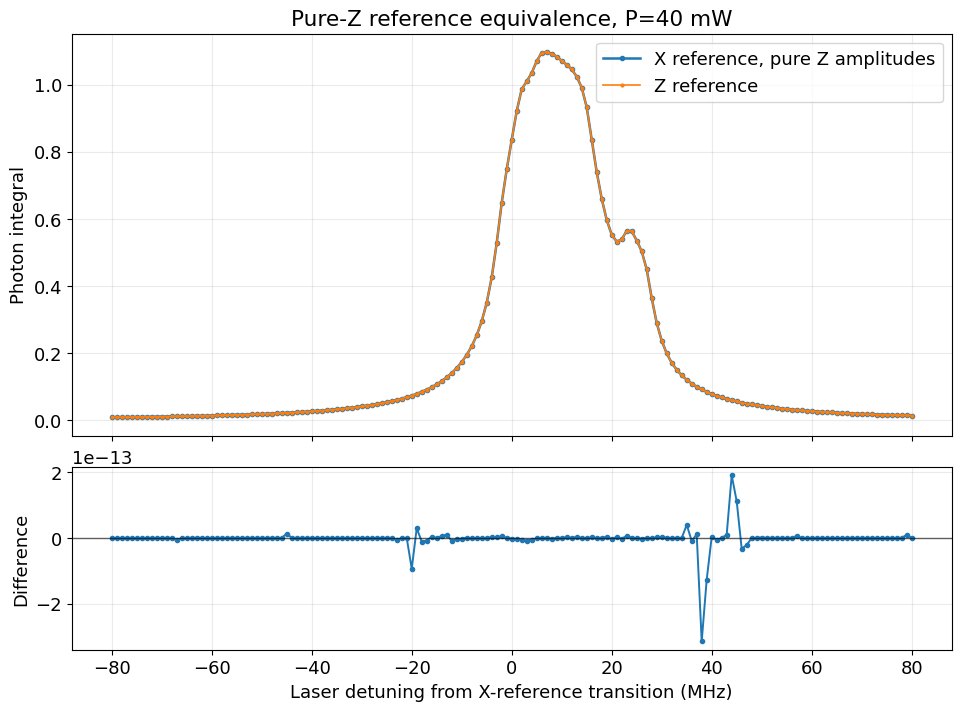

In [8]:
fig, (ax_trace, ax_resid) = plt.subplots(
    2,
    1,
    figsize=(9.5, 7.0),
    sharex=True,
    constrained_layout=True,
    height_ratios=[2.2, 1.0],
)

ax_trace.plot(
    SHARED_X_REFERENCE_DETUNING_MHZ,
    photons_x_reference,
    marker="o",
    ms=3,
    lw=1.8,
    label="X reference, pure Z amplitudes",
)
ax_trace.plot(
    SHARED_X_REFERENCE_DETUNING_MHZ,
    photons_z_reference,
    marker=".",
    ms=4,
    lw=1.2,
    label="Z reference",
)
ax_trace.set_ylabel("Photon integral")
ax_trace.set_title(f"Pure-Z reference equivalence, P={POWER_MW:g} mW")
ax_trace.grid(alpha=0.25)
ax_trace.legend()

ax_resid.plot(SHARED_X_REFERENCE_DETUNING_MHZ, residual, marker="o", ms=3, lw=1.4)
ax_resid.axhline(0.0, color="k", lw=1.0, alpha=0.6)
ax_resid.set_xlabel("Laser detuning from X-reference transition (MHz)")
ax_resid.set_ylabel("Difference")
ax_resid.grid(alpha=0.25)


In [9]:
np.testing.assert_allclose(
    photons_x_reference,
    photons_z_reference,
    rtol=ASSERT_RTOL,
    atol=ASSERT_ATOL,
)
